# Initialisation: Pleiades



Forward-mode
num = 1 | elapsed = 0.00 | max_time = 0.5
num = 2 | elapsed = 0.06 | max_time = 0.5
num = 3 | elapsed = 0.08 | max_time = 0.5


num = 4 | elapsed = 0.13 | max_time = 0.5
num = 5 | elapsed = 0.20 | max_time = 0.5


num = 6 | elapsed = 0.35 | max_time = 0.5


num = 7 | elapsed = 0.80 | max_time = 0.5


Taylor-mode (scan)
num = 1 | elapsed = 0.00 | max_time = 0.5
num = 2 | elapsed = 0.06 | max_time = 0.5
num = 3 | elapsed = 0.10 | max_time = 0.5


num = 4 | elapsed = 0.19 | max_time = 0.5
num = 5 | elapsed = 0.21 | max_time = 0.5


...

num = 6 | elapsed = 0.26 | max_time = 0.5


num = 7 | elapsed = 0.33 | max_time = 0.5


num = 8 | elapsed = 0.35 | max_time = 0.5


num = 9 | elapsed = 0.48 | max_time = 0.5


num = 10 | elapsed = 0.78 | max_time = 0.5


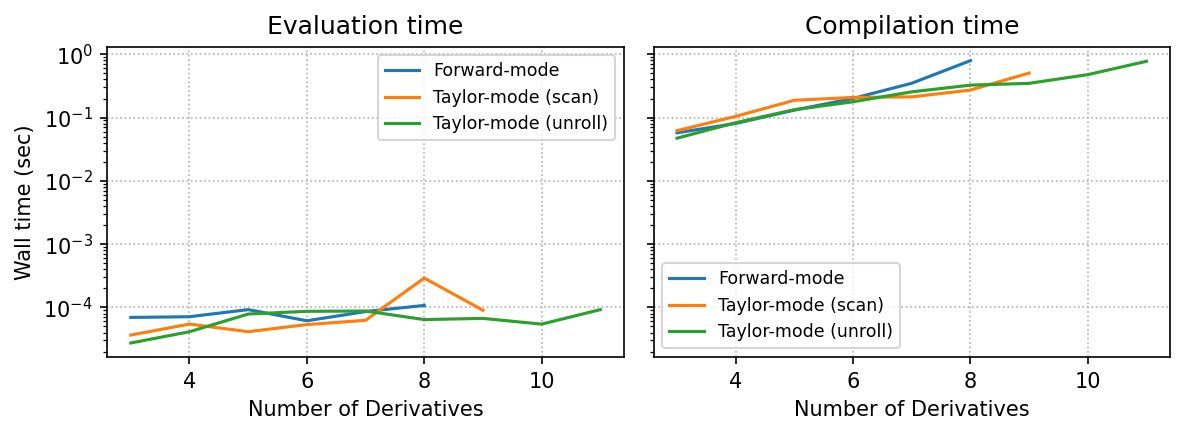

In [1]:
"""Benchmark the initialisation methods on the Pleiades problem."""

import functools
import statistics
import time
import timeit
from collections.abc import Callable

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probdiffeq import taylor

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)


def main(max_time=0.5, repeats=2) -> None:
    """Run the script."""
    # Set JAX config
    jax.config.update("jax_enable_x64", True)

    algorithms = {
        r"Forward-mode": odejet_via_jvp(),
        r"Taylor-mode (scan)": taylor_mode_scan(),
        r"Taylor-mode (unroll)": taylor_mode_unroll(),
    }

    # Compute a reference solution
    timeit_fun = timeit_fun_from_args(repeats=repeats)

    # Compute all work-precision diagrams
    results = {}
    for label, algo in algorithms.items():
        print("\n")
        print(label)
        results[label] = adaptive_benchmark(
            algo, timeit_fun=timeit_fun, max_time=max_time
        )

    _fig, (axis_perform, axis_compile) = plt.subplots(
        ncols=2, figsize=(8, 3), dpi=150, sharex=True, sharey=True
    )

    for label, wp in results.items():
        inputs = wp["arguments"]
        work_compile = wp["work_compile"]
        work_mean, work_std = wp["work_mean"], wp["work_std"]

        if "doubling" in label:
            num_repeats = jnp.diff(jnp.concatenate((jnp.ones((1,)), inputs)))
            inputs = jnp.arange(1, jnp.amax(inputs) * 1)
            work_compile = _adaptive_repeat(work_compile, num_repeats)
            work_mean = _adaptive_repeat(work_mean, num_repeats)
            work_std = _adaptive_repeat(work_std, num_repeats)

        axis_compile.semilogy(inputs, work_compile, label=label)
        axis_perform.semilogy(inputs, work_mean, label=label)

    axis_compile.set_title("Compilation time")
    axis_perform.set_title("Evaluation time")
    axis_perform.legend(fontsize="small")
    axis_compile.legend(fontsize="small")
    axis_compile.set_xlabel("Number of Derivatives")
    axis_perform.set_xlabel("Number of Derivatives")
    axis_perform.set_ylabel("Wall time (sec)")
    axis_perform.grid(linestyle="dotted")
    axis_compile.grid(linestyle="dotted")

    plt.tight_layout()
    plt.show()


def _adaptive_repeat(xs, ys):
    """Repeat the doubling values correctly to create a comprehensible plot."""
    zs = []
    for x, y in zip(xs, ys):
        zs.extend([x] * int(y))
    return jnp.asarray(zs)


def timeit_fun_from_args(*, repeats: int) -> Callable:
    """Construct a timeit-function from the command-line arguments."""

    def timer(fun, /):
        return list(timeit.repeat(fun, number=1, repeat=repeats))

    return timer


def taylor_mode_scan() -> Callable:
    """Taylor-mode estimation."""
    vf_auto, (u0, du0) = _pleiades()

    @functools.partial(jax.jit, static_argnames=["num"])
    def estimate(num):
        tcoeffs = taylor.odejet_padded_scan(vf_auto, (u0, du0), num=num)
        return jnp.asarray(tcoeffs)

    return estimate


def taylor_mode_unroll() -> Callable:
    """Taylor-mode estimation."""
    vf_auto, (u0, du0) = _pleiades()

    @functools.partial(jax.jit, static_argnames=["num"])
    def estimate(num):
        tcoeffs = taylor.odejet_unroll(vf_auto, (u0, du0), num=num)
        return jnp.asarray(tcoeffs)

    return estimate


def odejet_via_jvp() -> Callable:
    """Forward-mode estimation."""
    vf_auto, (u0, du0) = _pleiades()

    @functools.partial(jax.jit, static_argnames=["num"])
    def estimate(num):
        tcoeffs = taylor.odejet_via_jvp(vf_auto, (u0, du0), num=num)
        return jnp.asarray(tcoeffs)

    return estimate


def _pleiades():
    # fmt: off
    u0 = jnp.asarray(
        [
            3.0,  3.0, -1.0, -3.00, 2.0, -2.00,  2.0,
            3.0, -3.0,  2.0,  0.00, 0.0, -4.00,  4.0,
        ]
    )
    du0 = jnp.asarray(
        [
            0.0,  0.0,  0.0,  0.00, 0.0,  1.75, -1.5,
            0.0,  0.0,  0.0, -1.25, 1.0,  0.00,  0.0,
        ]
    )
    # fmt: on
    t0 = 0.0

    @jax.jit
    def vf_probdiffeq(u, du, *, t=t0):  # noqa: ARG001
        """Pleiades problem."""
        x = u[0:7]  # x
        y = u[7:14]  # y
        xi, xj = x[:, None], x[None, :]
        yi, yj = y[:, None], y[None, :]
        rij = ((xi - xj) ** 2 + (yi - yj) ** 2) ** (3 / 2)
        mj = jnp.arange(1, 8)[None, :]
        ddx = jnp.sum(jnp.nan_to_num(mj * (xj - xi) / rij), axis=1)
        ddy = jnp.sum(jnp.nan_to_num(mj * (yj - yi) / rij), axis=1)
        return jnp.concatenate((ddx, ddy))

    return vf_probdiffeq, (u0, du0)


def adaptive_benchmark(fun, *, timeit_fun: Callable, max_time) -> dict:
    """Benchmark a function iteratively until a max-time threshold is exceeded."""
    work_compile = []
    work_mean = []
    work_std = []
    arguments = []

    t0 = time.perf_counter()
    arg = 1
    while (elapsed := time.perf_counter() - t0) < max_time:
        print(f"num = {arg} | elapsed = {elapsed:.2f} | max_time = {max_time}")
        t0 = time.perf_counter()
        tcoeffs = fun(arg).block_until_ready()
        t1 = time.perf_counter()
        time_compile = t1 - t0

        time_execute = timeit_fun(lambda: fun(arg).block_until_ready())  # noqa: B023

        arguments.append(len(tcoeffs))
        work_compile.append(time_compile)
        work_mean.append(statistics.mean(time_execute))
        work_std.append(statistics.stdev(time_execute))
        arg += 1
    print(f"num = {arg} | elapsed = {elapsed:.2f} | max_time = {max_time}")
    return {
        "work_mean": jnp.asarray(work_mean),
        "work_std": jnp.asarray(work_std),
        "work_compile": jnp.asarray(work_compile),
        "arguments": jnp.asarray(arguments),
    }


main()